In [2]:
# Chỉ cài timm cho mô hình Swin. Không đụng chạm gì tới các thư viện dò mặt hay numpy!
!pip install timm -q
print("✅ Cài đặt xong! Môi trường hoàn toàn sạch sẽ.")

✅ Cài đặt xong! Môi trường hoàn toàn sạch sẽ.


In [3]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Môi trường đã sẵn sàng! Đang huấn luyện bằng: {device}")
# Nhớ đảm bảo góc phải Kaggle đang bật GPU T4 x2 nhé!

🚀 Môi trường đã sẵn sàng! Đang huấn luyện bằng: cuda


In [4]:
# ======================================================
# 1. ĐƯỜNG DẪN INPUT FF++ C23
# ======================================================
REAL_DIR = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original'
FAKE_DF_DIR = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Deepfakes'
FAKE_F2F_DIR = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face'

OUT_DIR = '/kaggle/working/dataset'
for split in ['train', 'val']:
    for label in ['real', 'fake']:
        os.makedirs(os.path.join(OUT_DIR, split, label), exist_ok=True)

print("🔍 Đang quét dữ liệu FF++...")
real_vids = glob.glob(f"{REAL_DIR}/**/*.mp4", recursive=True)
fake_vids = glob.glob(f"{FAKE_DF_DIR}/**/*.mp4", recursive=True) + glob.glob(f"{FAKE_F2F_DIR}/**/*.mp4", recursive=True)

if len(real_vids) == 0 or len(fake_vids) == 0:
    raise ValueError("❌ Không tìm thấy video. Kiểm tra lại đường dẫn!")

# Cân bằng 1000 - 1000
NUM_VIDEOS = min(1000, len(real_vids), len(fake_vids))
real_vids = random.sample(real_vids, NUM_VIDEOS)
fake_vids = random.sample(fake_vids, NUM_VIDEOS)

train_real, val_real = train_test_split(real_vids, test_size=0.2, random_state=42)
train_fake, val_fake = train_test_split(fake_vids, test_size=0.2, random_state=42)

splits = {
    'train/real': train_real, 'train/fake': train_fake,
    'val/real': val_real, 'val/fake': val_fake
}

# ======================================================
# 2. CẮT MẶT BẰNG AI CỦA OPENCV (Không cần tải thư viện)
# ======================================================
# Gọi mô hình nhận diện khuôn mặt tích hợp sẵn trong Kaggle OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def extract_faces_opencv(video_list, save_path, frames_per_vid=4):
    count = 0
    for vid_path in tqdm(video_list, desc=f"Đang cắt -> {save_path.split('/')[-2:]}"):
        cap = cv2.VideoCapture(vid_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0: 
            cap.release()
            continue
            
        target_frames = set([int(i * total_frames / frames_per_vid) for i in range(frames_per_vid)])
        vid_name = os.path.basename(vid_path).split('.')[0]
        
        current_frame = 0
        saved = 0
        
        while True:
            ret = cap.grab()
            if not ret: break
                
            if current_frame in target_frames:
                ret, frame = cap.retrieve()
                if ret:
                    # OpenCV Haar Cascade cần ảnh xám (Grayscale) để nhận diện nhanh
                    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
                    
                    if len(faces) > 0:
                        # Lấy khuôn mặt to nhất (tránh nhận diện nhầm chi tiết nhỏ)
                        faces = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)
                        x, y, w, h = faces[0]
                        ih, iw = frame.shape[:2]
                        
                        pad_x, pad_y = int(w * 0.1), int(h * 0.15)
                        x1, y1 = max(0, x - pad_x), max(0, y - pad_y * 2) 
                        x2, y2 = min(iw, x + w + pad_x), min(ih, y + h + pad_y)
                        
                        face_crop = frame[y1:y2, x1:x2]
                        if face_crop.size > 0:
                            cv2.imwrite(os.path.join(save_path, f"{vid_name}_{saved}.jpg"), face_crop)
                            count += 1
                saved += 1
                if saved >= frames_per_vid: break 
            current_frame += 1
        cap.release()
    return count

for split_name, vid_list in splits.items():
    extracted = extract_faces_opencv(vid_list, os.path.join(OUT_DIR, split_name))
    print(f"✅ Đã cắt {extracted} ảnh cho tập {split_name}")

🔍 Đang quét dữ liệu FF++...


Đang cắt -> ['train', 'real']:   0%|          | 0/800 [00:00<?, ?it/s]

✅ Đã cắt 3188 ảnh cho tập train/real


Đang cắt -> ['train', 'fake']:   0%|          | 0/800 [00:00<?, ?it/s]

✅ Đã cắt 3180 ảnh cho tập train/fake


Đang cắt -> ['val', 'real']:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Đã cắt 795 ảnh cho tập val/real


Đang cắt -> ['val', 'fake']:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Đã cắt 796 ảnh cho tập val/fake


In [6]:
swin_train_tf = transforms.Compose([
    transforms.ToPILImage(), transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

swin_val_tf = transforms.Compose([
    transforms.ToPILImage(), transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

rppg_tf = transforms.Compose([transforms.ToPILImage(), transforms.Resize((64, 64)), transforms.ToTensor()])

class DeepfakeFusionDataset(Dataset):
    def __init__(self, root_dir, is_train=True):
        self.paths, self.labels = [], []
        for label, folder in enumerate(['real', 'fake']):
            path = os.path.join(root_dir, folder)
            for f in os.listdir(path):
                self.paths.append(os.path.join(path, f))
                self.labels.append(label)
        self.swin_tf = swin_train_tf if is_train else swin_val_tf
        self.rppg_tf = rppg_tf

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb) # Tách mạch máu YCrCb
        
        return self.swin_tf(img_rgb), self.rppg_tf(img_ycrcb), torch.tensor(self.labels[idx], dtype=torch.float32)

train_loader = DataLoader(DeepfakeFusionDataset('/kaggle/working/dataset/train', is_train=True), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(DeepfakeFusionDataset('/kaggle/working/dataset/val', is_train=False), batch_size=32, shuffle=False, num_workers=2)
print("📦 Tạo ống dẫn dữ liệu thành công!")

📦 Tạo ống dẫn dữ liệu thành công!


In [9]:
# Cài đặt công cụ vẽ bảng thông số mô hình
!pip install torchinfo -q

import torch
import torch.nn as nn
import timm
from torchinfo import summary

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim_visual=768, dim_bio=64, num_heads=8):
        super().__init__()
        self.bio_proj = nn.Linear(dim_bio, dim_visual)
        self.cross_attn = nn.MultiheadAttention(embed_dim=dim_visual, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(dim_visual)
        
    def forward(self, visual_feat, bio_feat):
        v_q = visual_feat.unsqueeze(1)
        b_kv = self.bio_proj(bio_feat).unsqueeze(1)
        attn_out, _ = self.cross_attn(query=v_q, key=b_kv, value=b_kv)
        return self.norm(v_q + attn_out).squeeze(1)

class AdvancedDeepfakeModel(nn.Module):
    def __init__(self):
        super(AdvancedDeepfakeModel, self).__init__()
        # Backbone Swin-T
        self.swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        
        # Backbone rPPG
        self.rppg_net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # Cross-Attention
        self.can_fusion = CrossAttentionFusion(dim_visual=768, dim_bio=64)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, 1), nn.Sigmoid()
        )

    def forward(self, image_input, rppg_input):
        visual_features = self.swin(image_input)
        bio_features = torch.flatten(self.rppg_net(rppg_input), 1)
        fused_features = self.can_fusion(visual_features, bio_features)
        return self.classifier(fused_features)

# Khởi tạo mô hình và đưa lên GPU
model = AdvancedDeepfakeModel().to(device)

print("✅ Khởi tạo Kiến trúc hoàn tất!\n")
print("="*60)
print("📊 BẢNG THÔNG SỐ CHI TIẾT MÔ HÌNH (MODEL SUMMARY)")
print("="*60)

# Hiển thị bảng chi tiết với 2 Input: Swin (Batch=32, C=3, H=224, W=224) và rPPG (Batch=32, C=3, H=64, W=64)
summary(
    model, 
    input_size=[(32, 3, 224, 224), (32, 3, 64, 64)], 
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    row_settings=["var_names"]
)

✅ Khởi tạo Kiến trúc hoàn tất!

📊 BẢNG THÔNG SỐ CHI TIẾT MÔ HÌNH (MODEL SUMMARY)


Layer (type (var_name))                                 Input Shape        Output Shape       Param #            Trainable
AdvancedDeepfakeModel (AdvancedDeepfakeModel)           [32, 3, 224, 224]  [32, 1]            --                 True
├─SwinTransformer (swin)                                [32, 3, 224, 224]  [32, 768]          --                 True
│    └─PatchEmbed (patch_embed)                         [32, 3, 224, 224]  [32, 56, 56, 96]   --                 True
│    │    └─Conv2d (proj)                               [32, 3, 224, 224]  [32, 96, 56, 56]   4,704              True
│    │    └─LayerNorm (norm)                            [32, 56, 56, 96]   [32, 56, 56, 96]   192                True
│    └─Sequential (layers)                              [32, 56, 56, 96]   [32, 7, 7, 768]    --                 True
│    │    └─SwinTransformerStage (0)                    [32, 56, 56, 96]   [32, 56, 56, 96]   224,694            True
│    │    └─SwinTransformerStage (1)               

In [10]:
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
criterion = nn.BCELoss()

epochs = 30
best_auc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"🚀 BẮT ĐẦU QUÁ TRÌNH HỌC ({epochs} EPOCHS)")

for epoch in range(epochs):
    model.train()
    run_loss = 0.0
    for imgs, rppgs, labels in train_loader:
        imgs, rppgs, labels = imgs.to(device), rppgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs, rppgs).squeeze(1)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item()
        
    scheduler.step()
    history['train_loss'].append(run_loss/len(train_loader))

    model.eval()
    v_loss = 0.0
    preds, tgts = [], []
    with torch.no_grad():
        for imgs, rppgs, labels in val_loader:
            imgs, rppgs, labels = imgs.to(device), rppgs.to(device), labels.to(device)
            out = model(imgs, rppgs).squeeze(1)
            if out.dim()==0: out = out.unsqueeze(0)
            v_loss += criterion(out, labels).item()
            preds.extend(out.cpu().numpy())
            tgts.extend(labels.cpu().numpy())
            
    history['val_loss'].append(v_loss/len(val_loader))
    acc = accuracy_score(tgts, [1 if p>0.5 else 0 for p in preds])
    auc = roc_auc_score(tgts, preds)
    history['val_auc'].append(auc)

    print(f"🔄 Epoch [{epoch+1}/{epochs}] | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f}")
    print(f"   🎯 Val Acc: {acc*100:.2f}% | 📈 Val AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), '/kaggle/working/Swin_CAN_rPPG_best.pth')
        print(f"   ⭐ LƯU TRỌNG SỐ THÀNH CÔNG (Đạt đỉnh AUC: {best_auc:.4f})")

🚀 BẮT ĐẦU QUÁ TRÌNH HỌC (30 EPOCHS)
🔄 Epoch [1/30] | Train Loss: 0.5849 | Val Loss: 0.5743
   🎯 Val Acc: 71.82% | 📈 Val AUC: 0.9354
   ⭐ LƯU TRỌNG SỐ THÀNH CÔNG (Đạt đỉnh AUC: 0.9354)
🔄 Epoch [2/30] | Train Loss: 0.2349 | Val Loss: 0.2541
   🎯 Val Acc: 89.01% | 📈 Val AUC: 0.9760
   ⭐ LƯU TRỌNG SỐ THÀNH CÔNG (Đạt đỉnh AUC: 0.9760)
🔄 Epoch [3/30] | Train Loss: 0.1448 | Val Loss: 0.1706
   🎯 Val Acc: 93.21% | 📈 Val AUC: 0.9825
   ⭐ LƯU TRỌNG SỐ THÀNH CÔNG (Đạt đỉnh AUC: 0.9825)
🔄 Epoch [4/30] | Train Loss: 0.1115 | Val Loss: 0.1600
   🎯 Val Acc: 93.47% | 📈 Val AUC: 0.9888
   ⭐ LƯU TRỌNG SỐ THÀNH CÔNG (Đạt đỉnh AUC: 0.9888)
🔄 Epoch [5/30] | Train Loss: 0.0836 | Val Loss: 0.1687
   🎯 Val Acc: 93.54% | 📈 Val AUC: 0.9887
🔄 Epoch [6/30] | Train Loss: 0.0675 | Val Loss: 0.1541
   🎯 Val Acc: 94.38% | 📈 Val AUC: 0.9887
🔄 Epoch [7/30] | Train Loss: 0.0576 | Val Loss: 0.1482
   🎯 Val Acc: 94.96% | 📈 Val AUC: 0.9896
   ⭐ LƯU TRỌNG SỐ THÀNH CÔNG (Đạt đỉnh AUC: 0.9896)
🔄 Epoch [8/30] | Train Loss: 0.0

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC 🏆
🔹 Độ chính xác (Accuracy) : 95.02%
🔹 Chỉ số AUC              : 0.9907
🔹 Chỉ số EER              : 5.41%


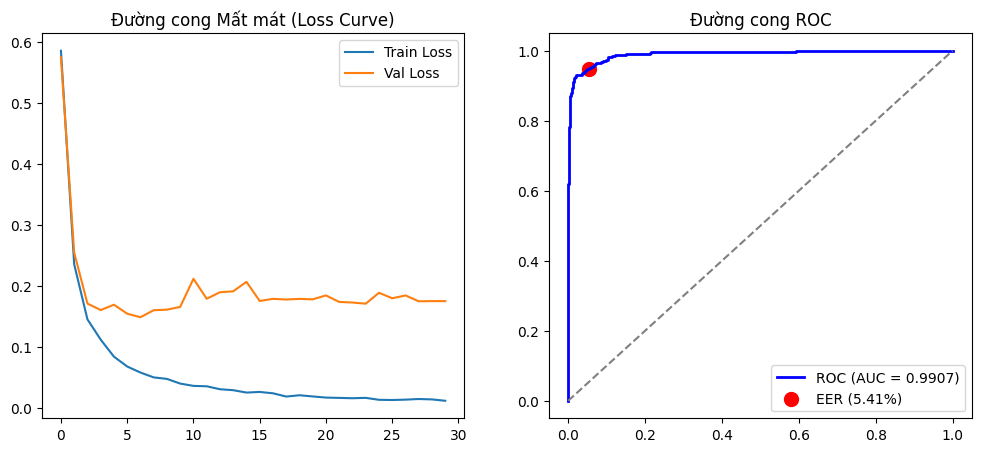

In [11]:
def compute_eer(labels, preds):
    fpr, tpr, _ = roc_curve(labels, preds)
    fnr = 1 - tpr
    idx = np.nanargmin(np.absolute(fnr - fpr))
    return fpr[idx], fpr, tpr

model.load_state_dict(torch.load('/kaggle/working/Swin_CAN_rPPG_best.pth'))
model.eval()

final_preds, final_tgts = [], []
with torch.no_grad():
    for imgs, rppgs, labels in val_loader:
        imgs, rppgs = imgs.to(device), rppgs.to(device)
        out = model(imgs, rppgs).squeeze(1)
        final_preds.extend(out.cpu().numpy())
        final_tgts.extend(labels.numpy())

acc = accuracy_score(final_tgts, [1 if p>0.5 else 0 for p in final_preds])
auc = roc_auc_score(final_tgts, final_preds)
eer, fpr, tpr = compute_eer(final_tgts, final_preds)

print("="*40)
print("🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC 🏆")
print("="*40)
print(f"🔹 Độ chính xác (Accuracy) : {acc*100:.2f}%")
print(f"🔹 Chỉ số AUC              : {auc:.4f}")
print(f"🔹 Chỉ số EER              : {eer*100:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Đường cong Mất mát (Loss Curve)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
eer_idx = np.nanargmin(np.absolute((1-tpr) - fpr))
plt.scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=100, label=f'EER ({eer*100:.2f}%)')
plt.title('Đường cong ROC')
plt.legend()

plt.savefig('/kaggle/working/BaoCao_Swin_CAN_rPPG.png')
plt.show()